In [1]:
import math
import heapq
from pathlib import Path
import sys

utils_dir = Path("src/notebooks")
if utils_dir.exists() and str(utils_dir.resolve()) not in sys.path:
    sys.path.append(str(utils_dir.resolve()))

from utils import display_graph, display_mapping, display_path


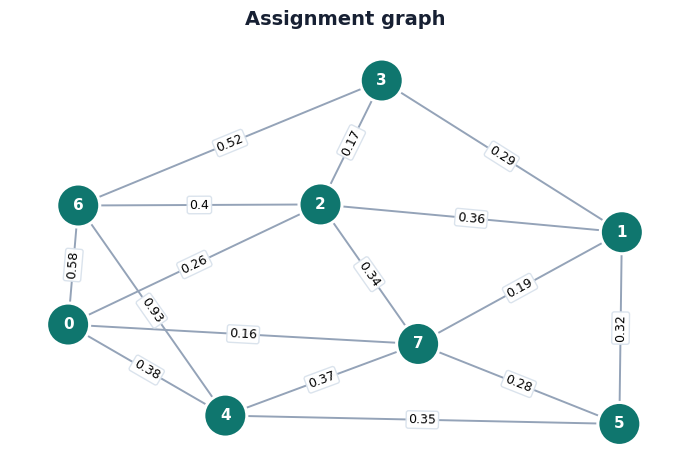

In [2]:
graph = {
    0: [(7, 0.16), (2, 0.26), (4, 0.38), (6, 0.58)],
    1: [(5, 0.32), (7, 0.19), (2, 0.36), (3, 0.29)],
    2: [(1, 0.36), (3, 0.17), (7, 0.34), (0, 0.26), (6, 0.40)],
    3: [(1, 0.29), (2, 0.17), (6, 0.52)],
    4: [(5, 0.35), (7, 0.37), (0, 0.38), (6, 0.93)],
    5: [(4, 0.35), (7, 0.28), (1, 0.32)],
    6: [(3, 0.52), (2, 0.40), (0, 0.58), (4, 0.93)],
    7: [(5, 0.28), (1, 0.19), (4, 0.37), (0, 0.16), (2, 0.34)]
}

display_graph(graph, title="Assignment graph")


In [14]:
lst = [(7, 0.16), (2, 0.26), (4, 0.38), (6, 0.58)]

item = next((x for x in lst if x[0] == 7), None)

print(item)

(7, 0.16)


In [30]:
def bellman_ford(graph: dict, source, debug = False):
    reverse_adjacency = {}

    # Get revese adjacency list
    def get_node_input(node):

        if node not in graph:
            raise ValueError(f"Cannot get node input because node {node} not in graph")

        if node in reverse_adjacency:
            return reverse_adjacency[node]
        else:
            predeccessors = []
            for node_, neighbors_ in graph.items():
                exists = any(x == node for x, _ in neighbors_)
                if exists:
                    predeccessors.append(node_)
            reverse_adjacency[node] = predeccessors
            return predeccessors
        
    if source not in graph:
        raise ValueError("Source node not in the graph")
    
    label = {}
    prev = {}

    for node, _ in graph.items():
        label[node] = math.inf
        prev[node] = -1
    label[source] = 0

    for i in range(1, len(graph) +1):   # +1 to check for negative cycle
        if debug:
            print(f"Loop {i}")
        for v in graph:

            # Dont consider source node
            if v == source:
                continue
            if debug:
                print(f"Consider node v: {v}")
            # Get all predeccessors of v
            list_u = get_node_input(v)
            for u in list_u:
                # Get distance between u and v
                u_neigbors = graph[u]
                distance_v = next((x for x in u_neigbors if x[0] == v), None)
                if not distance_v :
                    raise ValueError
                d_u_v = distance_v[1]

                if label[u] + d_u_v < label[v]:
                    if i == len(graph):
                        print("Contains circuit of negative weight")
                        raise ValueError
                    label[v] = label[u] + d_u_v
                    prev[v] = u

                    if debug:
                        print(f"Using node u : {u} to update path")
                        print(f"Label: {label}")
                        print(f"Prev: {prev}")
            if debug:
                print("-" * 100)
        if debug:
                print("-" * 100)
    
    return label, prev

In [31]:
label, prev = bellman_ford(graph, 0)

display_mapping(label, title="Final labels from source 0", key_name="Node", value_name="Distance")
display_mapping(prev, title="Previous node table", key_name="Node", value_name="Previous")


,Node,Distance
,0,0
,1,0.35
,2,0.26
,3,0.43
,4,0.38
,5,0.44
,6,0.58
,7,0.16


,Node,Previous
,0,-1
,1,7
,2,0
,3,2
,4,0
,5,7
,6,0
,7,0


'\n    \n    <style>\n      .algo-card {\n        --ink: #172033;\n        --muted: #667085;\n        --line: #d9e2ec;\n        --header: #0f766e;\n        --header-ink: #ffffff;\n        --body: #f8fafc;\n        --body-alt: #eef6f4;\n        display: inline-block;\n        margin: 10px 0 18px;\n        padding: 14px 16px 16px;\n        border: 1px solid var(--line);\n        border-radius: 8px;\n        background: #ffffff;\n        box-shadow: 0 10px 28px rgba(15, 23, 42, 0.10);\n        font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;\n        color: var(--ink);\n      }\n      .algo-title {\n        margin: 0 0 10px;\n        font-size: 15px;\n        font-weight: 750;\n        letter-spacing: 0;\n      }\n      .algo-caption {\n        margin: -4px 0 10px;\n        color: var(--muted);\n        font-size: 12px;\n      }\n      .algo-matrix {\n        border-collapse: separate;\n        border-spacing: 0;\n        overflow: h

In [32]:
label, prev = bellman_ford(graph, 0, debug=True)

display_mapping(label, title="Final labels from source 0", key_name="Node", value_name="Distance")
display_mapping(prev, title="Previous node table", key_name="Node", value_name="Previous")


Loop 1
Consider node v: 1
----------------------------------------------------------------------------------------------------
Consider node v: 2
Using node u : 0 to update path
Label: {0: 0, 1: inf, 2: 0.26, 3: inf, 4: inf, 5: inf, 6: inf, 7: inf}
Prev: {0: -1, 1: -1, 2: 0, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1}
----------------------------------------------------------------------------------------------------
Consider node v: 3
Using node u : 2 to update path
Label: {0: 0, 1: inf, 2: 0.26, 3: 0.43000000000000005, 4: inf, 5: inf, 6: inf, 7: inf}
Prev: {0: -1, 1: -1, 2: 0, 3: 2, 4: -1, 5: -1, 6: -1, 7: -1}
----------------------------------------------------------------------------------------------------
Consider node v: 4
Using node u : 0 to update path
Label: {0: 0, 1: inf, 2: 0.26, 3: 0.43000000000000005, 4: 0.38, 5: inf, 6: inf, 7: inf}
Prev: {0: -1, 1: -1, 2: 0, 3: 2, 4: 0, 5: -1, 6: -1, 7: -1}
-----------------------------------------------------------------------------------------

,Node,Distance
,0,0
,1,0.35
,2,0.26
,3,0.43
,4,0.38
,5,0.44
,6,0.58
,7,0.16


,Node,Previous
,0,-1
,1,7
,2,0
,3,2
,4,0
,5,7
,6,0
,7,0


'\n    \n    <style>\n      .algo-card {\n        --ink: #172033;\n        --muted: #667085;\n        --line: #d9e2ec;\n        --header: #0f766e;\n        --header-ink: #ffffff;\n        --body: #f8fafc;\n        --body-alt: #eef6f4;\n        display: inline-block;\n        margin: 10px 0 18px;\n        padding: 14px 16px 16px;\n        border: 1px solid var(--line);\n        border-radius: 8px;\n        background: #ffffff;\n        box-shadow: 0 10px 28px rgba(15, 23, 42, 0.10);\n        font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;\n        color: var(--ink);\n      }\n      .algo-title {\n        margin: 0 0 10px;\n        font-size: 15px;\n        font-weight: 750;\n        letter-spacing: 0;\n      }\n      .algo-caption {\n        margin: -4px 0 10px;\n        color: var(--muted);\n        font-size: 12px;\n      }\n      .algo-matrix {\n        border-collapse: separate;\n        border-spacing: 0;\n        overflow: h

In [33]:
def get_shortest_path(label, prev, dest):

    if dest not in label:
        raise ValueError("Destination is not in label") 
    shortest_path = [dest]
    prev_node = prev[dest]
    while prev_node != -1:
        shortest_path.append(prev_node)
        prev_node = prev[prev_node]
    return shortest_path[::-1], label[dest]

def pretty_print_sp(shortest_path, distance):
    display_path(shortest_path, title="Shortest path", cost=distance)


In [34]:
shortest_path , distance = get_shortest_path(label, prev, 2)
pretty_print_sp(shortest_path, distance)

## Test with graph in the slides

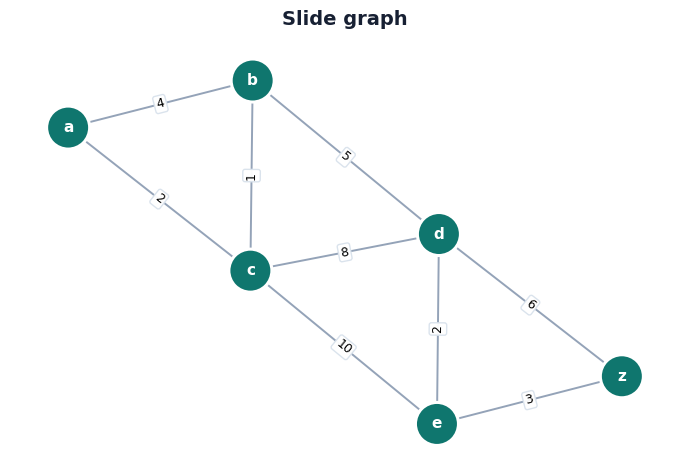

In [35]:
slide_graph = {
    "a": [("b", 4), ("c", 2)],
    "b": [("a", 4), ("c", 1), ("d", 5)],
    "c": [("a", 2), ("b", 1), ("d", 8), ("e", 10)],
    "d": [("b", 5), ("c", 8), ("e", 2), ("z", 6)],
    "e": [("c", 10), ("d", 2), ("z", 3)],
    "z": [("d", 6), ("e", 3)]
}

display_graph(slide_graph, title="Slide graph")


In [36]:
label, prev = bellman_ford(slide_graph, "a", debug = True)

display_mapping(label, title="Final labels from source a", key_name="Node", value_name="Distance")
display_mapping(prev, title="Previous node table", key_name="Node", value_name="Previous")


Loop 1
Consider node v: b
Using node u : a to update path
Label: {'a': 0, 'b': 4, 'c': inf, 'd': inf, 'e': inf, 'z': inf}
Prev: {'a': -1, 'b': 'a', 'c': -1, 'd': -1, 'e': -1, 'z': -1}
----------------------------------------------------------------------------------------------------
Consider node v: c
Using node u : a to update path
Label: {'a': 0, 'b': 4, 'c': 2, 'd': inf, 'e': inf, 'z': inf}
Prev: {'a': -1, 'b': 'a', 'c': 'a', 'd': -1, 'e': -1, 'z': -1}
----------------------------------------------------------------------------------------------------
Consider node v: d
Using node u : b to update path
Label: {'a': 0, 'b': 4, 'c': 2, 'd': 9, 'e': inf, 'z': inf}
Prev: {'a': -1, 'b': 'a', 'c': 'a', 'd': 'b', 'e': -1, 'z': -1}
----------------------------------------------------------------------------------------------------
Consider node v: e
Using node u : c to update path
Label: {'a': 0, 'b': 4, 'c': 2, 'd': 9, 'e': 12, 'z': inf}
Prev: {'a': -1, 'b': 'a', 'c': 'a', 'd': 'b', 'e': '

,Node,Distance
,a,0
,b,3
,c,2
,d,8
,e,10
,z,13


,Node,Previous
,a,-1
,b,c
,c,a
,d,b
,e,d
,z,e


'\n    \n    <style>\n      .algo-card {\n        --ink: #172033;\n        --muted: #667085;\n        --line: #d9e2ec;\n        --header: #0f766e;\n        --header-ink: #ffffff;\n        --body: #f8fafc;\n        --body-alt: #eef6f4;\n        display: inline-block;\n        margin: 10px 0 18px;\n        padding: 14px 16px 16px;\n        border: 1px solid var(--line);\n        border-radius: 8px;\n        background: #ffffff;\n        box-shadow: 0 10px 28px rgba(15, 23, 42, 0.10);\n        font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;\n        color: var(--ink);\n      }\n      .algo-title {\n        margin: 0 0 10px;\n        font-size: 15px;\n        font-weight: 750;\n        letter-spacing: 0;\n      }\n      .algo-caption {\n        margin: -4px 0 10px;\n        color: var(--muted);\n        font-size: 12px;\n      }\n      .algo-matrix {\n        border-collapse: separate;\n        border-spacing: 0;\n        overflow: h